# EVO-ECO Matrix: Cellular Plasticity as a Markov Decision Process
## Q-Learning Simulation — Cancer Cell Survival Strategy

**Core question:** At what metabolic cost does phenotypic plasticity become worse than proliferating and waiting for a random mutation?

## Biology Rules (MOCK — Replace with real rules from biology team)

Everything the biology students define goes here. Swap out the values below once they provide their rules. The engine below reads from `BioConfig` and does NOT need to change.

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# BIOLOGY RULES — MOCK VALUES (replace with biology team input)
# ============================================================

class BioConfig:
    """
    All biology-defined parameters live here.
    Biology students: update ONLY this class.
    """

    # --- STATES ---
    # Each state represents a cell phenotype.
    # Format: {state_index: "label"}
    STATES = {
        0: "Differentiated",   # normal tumor cell
        1: "Stem-like",        # de-differentiated, therapy-resistant
        2: "Mutant-resistant",  # acquired genetic resistance (absorbing / terminal)
    }
    NUM_STATES = len(STATES)

    # --- ACTIONS ---
    # What the cell can "do" each generation.
    ACTIONS = {
        0: "Proliferate",      # divide in place, no phenotype change
        1: "Dedifferentiate",  # switch toward stem-like (plasticity)
        2: "Differentiate",    # switch toward differentiated
        3: "Wait",             # quiescent — do nothing
    }
    NUM_ACTIONS = len(ACTIONS)

    # --- THERAPY ENVIRONMENT ---
    THERAPY_KILL_PROB = {
        # Probability the therapy kills the cell in each state
        0: 0.60,   # differentiated: vulnerable
        1: 0.15,   # stem-like: resistant
        2: 0.05,   # mutant-resistant: nearly immune
    }

    # --- MUTATION ---
    # Probability of acquiring permanent genetic resistance per generation
    # (only while proliferating)
    MUTATION_PROB = 0.002

    # --- REWARD FUNCTION ---
    # Base survival reward each generation the cell stays alive
    SURVIVAL_REWARD = 1.0

    # Bonus for reaching permanent genetic resistance
    MUTATION_RESISTANCE_BONUS = 10.0

    # Metabolic cost of dedifferentiation (plasticity cost).
    # >>> THIS IS THE PARAMETER WE SWEEP <<<
    # Set a default here; the sweep loop will override it.
    PLASTICITY_COST = 0.3

    # Small cost for just proliferating (energy spent dividing)
    PROLIFERATION_COST = 0.05

    # Cost of doing nothing (quiescence penalty — not growing)
    QUIESCENCE_COST = 0.10

    # Cost of differentiating (small, going "with the grain")
    DIFFERENTIATION_COST = 0.02

    # --- TRANSITION LOGIC ---
    @staticmethod
    def transition(state, action, plasticity_cost_override=None):
        """
        Given current state and action, return (next_state, reward, done).
        `done` = True means the cell died or reached absorbing state.

        Biology students: modify this to match your model.
        """
        reward = BioConfig.SURVIVAL_REWARD
        plast_cost = plasticity_cost_override if plasticity_cost_override is not None else BioConfig.PLASTICITY_COST

        # --- If already mutant-resistant, stay there (absorbing state) ---
        if state == 2:
            return 2, reward + BioConfig.MUTATION_RESISTANCE_BONUS, False

        # --- Apply action effects ---
        next_state = state

        if action == 0:  # Proliferate
            reward -= BioConfig.PROLIFERATION_COST
            # Chance of gaining permanent resistance via mutation
            if np.random.rand() < BioConfig.MUTATION_PROB:
                return 2, reward + BioConfig.MUTATION_RESISTANCE_BONUS, False
            next_state = state  # stay in same phenotype

        elif action == 1:  # Dedifferentiate (plasticity)
            reward -= plast_cost
            # Move toward stem-like
            if state == 0:
                next_state = 1
            else:
                next_state = 1  # already stem-like, stay

        elif action == 2:  # Differentiate
            reward -= BioConfig.DIFFERENTIATION_COST
            if state == 1:
                next_state = 0
            else:
                next_state = 0  # already differentiated, stay

        elif action == 3:  # Wait (quiescence)
            reward -= BioConfig.QUIESCENCE_COST
            next_state = state

        # --- Therapy check: does the cell survive this generation? ---
        kill_prob = BioConfig.THERAPY_KILL_PROB[next_state]
        if np.random.rand() < kill_prob:
            return next_state, -1.0, True  # cell dies

        return next_state, reward, False

print("Biology rules loaded.")
print(f"  States:  {list(BioConfig.STATES.values())}")
print(f"  Actions: {list(BioConfig.ACTIONS.values())}")
print(f"  Default plasticity cost: {BioConfig.PLASTICITY_COST}")

Biology rules loaded.
  States:  ['Differentiated', 'Stem-like', 'Mutant-resistant']
  Actions: ['Proliferate', 'Dedifferentiate', 'Differentiate', 'Wait']
  Default plasticity cost: 0.3


## BioConfig Flowchart — State Transition Diagram

Visual map of the cancer cell MDP: states, actions, transition costs, therapy kill probabilities, and mutation path.

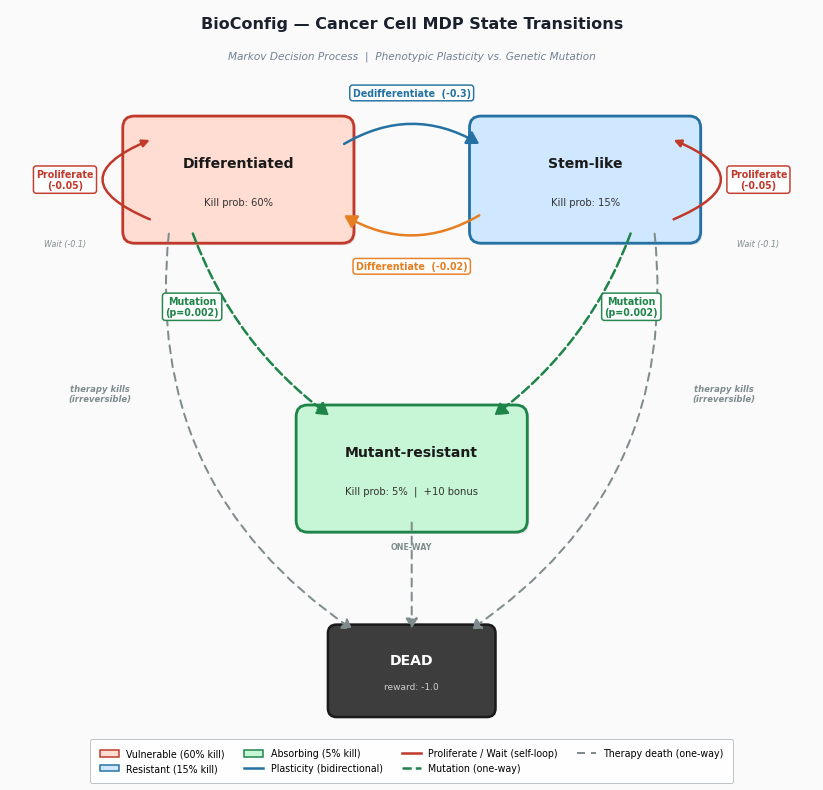

Flowchart saved to bioconfig_flowchart.png


In [13]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, ArrowStyle
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(14, 11))
ax.set_xlim(-1, 13)
ax.set_ylim(-0.5, 12.5)
ax.set_aspect('equal')
ax.axis('off')
fig.patch.set_facecolor('#FAFAFA')

# ── Fonts ──
TITLE_FS = 16
STATE_FS = 14
SUB_FS = 10
ARROW_FS = 9.5
LEGEND_FS = 9.5

# ── State positions ──
pos = {
    "diff":   (3.0, 9.5),
    "stem":   (9.0, 9.5),
    "mutant": (6.0, 4.5),
    "dead":   (6.0, 1.0),
}
BOX_W, BOX_H = 3.6, 1.8
SMALL_W, SMALL_H = 2.6, 1.3

# ── Draw state box ──
def draw_state(ax, cx, cy, w, h, name, subtitle, color, border_color):
    box = FancyBboxPatch((cx - w/2, cy - h/2), w, h,
                         boxstyle="round,pad=0.2", facecolor=color,
                         edgecolor=border_color, linewidth=2.8, zorder=3)
    box.set_path_effects([pe.withSimplePatchShadow(offset=(2, -2),
                         shadow_rgbFace='#BBBBBB', alpha=0.35)])
    ax.add_patch(box)
    ax.text(cx, cy + 0.28, name, ha='center', va='center', fontsize=STATE_FS,
            fontweight='bold', color='#1A1A1A', zorder=4)
    ax.text(cx, cy - 0.38, subtitle, ha='center', va='center', fontsize=SUB_FS,
            color='#333333', zorder=4)

# 3 main states
draw_state(ax, *pos["diff"], BOX_W, BOX_H,
           "Differentiated", f"Kill prob: {BioConfig.THERAPY_KILL_PROB[0]:.0%}",
           '#FFDDD2', '#C0392B')
draw_state(ax, *pos["stem"], BOX_W, BOX_H,
           "Stem-like", f"Kill prob: {BioConfig.THERAPY_KILL_PROB[1]:.0%}",
           '#D0E8FF', '#2471A3')
draw_state(ax, *pos["mutant"], BOX_W, BOX_H,
           "Mutant-resistant", f"Kill prob: {BioConfig.THERAPY_KILL_PROB[2]:.0%}  |  +{BioConfig.MUTATION_RESISTANCE_BONUS:.0f} bonus",
           '#C6F6D5', '#1E8449')

# Dead state
dead_box = FancyBboxPatch((pos["dead"][0] - SMALL_W/2, pos["dead"][1] - SMALL_H/2),
                          SMALL_W, SMALL_H,
                          boxstyle="round,pad=0.15", facecolor='#3D3D3D',
                          edgecolor='#1A1A1A', linewidth=2.5, zorder=3)
ax.add_patch(dead_box)
ax.text(pos["dead"][0], pos["dead"][1] + 0.18, "DEAD", ha='center', va='center',
        fontsize=STATE_FS, fontweight='bold', color='white', zorder=4)
ax.text(pos["dead"][0], pos["dead"][1] - 0.28, "reward: -1.0", ha='center', va='center',
        fontsize=SUB_FS - 1, color='#CCCCCC', zorder=4)

# ── Arrow helper with prominent arrowheads ──
def arrow(ax, start, end, label, color, rad=0.0, ls='-', lw=2.5, fs=ARROW_FS,
          lbl_offset=(0, 0), head_l=10, head_w=6):
    arr = FancyArrowPatch(start, end,
                          arrowstyle=ArrowStyle('-|>', head_length=head_l, head_width=head_w),
                          connectionstyle=f"arc3,rad={rad}",
                          color=color, linewidth=lw, linestyle=ls, zorder=6)
    ax.add_patch(arr)
    if label:
        mx = (start[0] + end[0]) / 2 + lbl_offset[0]
        my = (start[1] + end[1]) / 2 + lbl_offset[1]
        ax.text(mx, my, label, ha='center', va='center', fontsize=fs, color=color,
                fontweight='bold', zorder=7,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor=color, alpha=0.97, linewidth=1.5))

# ═══════════════════════════════════════════
# TRANSITIONS — all with bold visible arrows
# ═══════════════════════════════════════════

# 1. Dedifferentiate: Diff → Stem (top arc)
arrow(ax, (4.8, 10.1), (7.2, 10.1),
      f"Dedifferentiate  (-{BioConfig.PLASTICITY_COST})",
      '#2471A3', rad=-0.3, lbl_offset=(0, 0.9))

# 2. Differentiate: Stem → Diff (bottom arc)
arrow(ax, (7.2, 8.9), (4.8, 8.9),
      f"Differentiate  (-{BioConfig.DIFFERENTIATION_COST})",
      '#E67E22', rad=-0.3, lbl_offset=(0, -0.9))

# 3. Proliferate self-loop: Differentiated
ax.annotate("", xy=(1.5, 10.2), xytext=(1.5, 8.8),
            arrowprops=dict(arrowstyle='-|>', color='#C0392B', lw=2.5,
                            connectionstyle="arc3,rad=-1.2",
                            mutation_scale=15), zorder=6)
ax.text(0.0, 9.5, f"Proliferate\n(-{BioConfig.PROLIFERATION_COST})", ha='center', va='center',
        fontsize=ARROW_FS, color='#C0392B', fontweight='bold', zorder=7,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='#C0392B', alpha=0.97, linewidth=1.5))
ax.text(0.0, 8.4, f"Wait (-{BioConfig.QUIESCENCE_COST})", ha='center', va='center',
        fontsize=8, color='#7F8C8D', style='italic', zorder=7)

# 4. Proliferate self-loop: Stem-like
ax.annotate("", xy=(10.5, 10.2), xytext=(10.5, 8.8),
            arrowprops=dict(arrowstyle='-|>', color='#C0392B', lw=2.5,
                            connectionstyle="arc3,rad=1.2",
                            mutation_scale=15), zorder=6)
ax.text(12.0, 9.5, f"Proliferate\n(-{BioConfig.PROLIFERATION_COST})", ha='center', va='center',
        fontsize=ARROW_FS, color='#C0392B', fontweight='bold', zorder=7,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='#C0392B', alpha=0.97, linewidth=1.5))
ax.text(12.0, 8.4, f"Wait (-{BioConfig.QUIESCENCE_COST})", ha='center', va='center',
        fontsize=8, color='#7F8C8D', style='italic', zorder=7)

# 5. Mutation: Diff → Mutant (dashed, bold)
arrow(ax, (2.2, 8.6), (4.6, 5.4),
      f"Mutation\n(p={BioConfig.MUTATION_PROB})",
      '#1E8449', rad=0.15, ls='--', lw=2.5, lbl_offset=(-1.2, 0.3))

# 6. Mutation: Stem → Mutant (dashed, bold)
arrow(ax, (9.8, 8.6), (7.4, 5.4),
      f"Mutation\n(p={BioConfig.MUTATION_PROB})",
      '#1E8449', rad=-0.15, ls='--', lw=2.5, lbl_offset=(1.2, 0.3))

# 7. Therapy → Dead (all 3 states, visible dotted)
death_color = '#7F8C8D'
death_ls = (0, (4, 3))
arrow(ax, (1.8, 8.6), (5.0, 1.7),
      "", death_color, rad=0.3, ls=death_ls, lw=2.0, head_l=8, head_w=5)
arrow(ax, (10.2, 8.6), (7.0, 1.7),
      "", death_color, rad=-0.3, ls=death_ls, lw=2.0, head_l=8, head_w=5)
arrow(ax, (6.0, 3.6), (6.0, 1.7),
      "", death_color, rad=0.0, ls=death_ls, lw=2.0, head_l=8, head_w=5)

# "IRREVERSIBLE" labels on one-way paths
ax.text(0.6, 5.8, "therapy kills\n(irreversible)", ha='center', va='center',
        fontsize=8.5, color='#7F8C8D', style='italic', fontweight='semibold', zorder=7)
ax.text(11.4, 5.8, "therapy kills\n(irreversible)", ha='center', va='center',
        fontsize=8.5, color='#7F8C8D', style='italic', fontweight='semibold', zorder=7)

# Directionality annotation
ax.text(6.0, 3.15, "ONE-WAY", ha='center', va='center',
        fontsize=8, color='#7F8C8D', fontweight='bold', zorder=7)

# ── Title ──
ax.text(6.0, 12.2, "BioConfig — Cancer Cell MDP State Transitions",
        ha='center', va='center', fontsize=TITLE_FS, fontweight='bold', color='#1A202C')
ax.text(6.0, 11.65, "Markov Decision Process  |  Phenotypic Plasticity vs. Genetic Mutation",
        ha='center', va='center', fontsize=10.5, color='#718096', style='italic')

# ── Legend ──
legend_elements = [
    mpatches.Patch(facecolor='#FFDDD2', edgecolor='#C0392B', lw=1.5, label='Vulnerable (60% kill)'),
    mpatches.Patch(facecolor='#D0E8FF', edgecolor='#2471A3', lw=1.5, label='Resistant (15% kill)'),
    mpatches.Patch(facecolor='#C6F6D5', edgecolor='#1E8449', lw=1.5, label='Absorbing (5% kill)'),
    plt.Line2D([0], [0], color='#2471A3', lw=2.5, label='Plasticity (bidirectional)'),
    plt.Line2D([0], [0], color='#C0392B', lw=2.5, label='Proliferate / Wait (self-loop)'),
    plt.Line2D([0], [0], color='#1E8449', lw=2.5, ls='--', label='Mutation (one-way)'),
    plt.Line2D([0], [0], color='#7F8C8D', lw=2, ls=(0, (4, 3)), label='Therapy death (one-way)'),
]
ax.legend(handles=legend_elements, loc='lower center', fontsize=LEGEND_FS,
          framealpha=0.97, edgecolor='#BDC3C7', ncol=4, fancybox=True,
          bbox_to_anchor=(0.5, -0.04), borderpad=1.0)

plt.tight_layout()
plt.savefig("bioconfig_flowchart.png", dpi=200, bbox_inches="tight", facecolor='#FAFAFA')
plt.show()
print("Flowchart saved to bioconfig_flowchart.png")

## Q-Learning Engine

This cell is **generic**. It reads states/actions/transitions from `BioConfig` and does not need to change when biology rules are updated.

In [14]:
class QLearningEngine:
    """
    Tabular Q-learning agent.
    Reads state/action dimensions from BioConfig.
    """

    def __init__(self, lr=0.1, gamma=0.95, epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01):
        self.lr = lr                # learning rate
        self.gamma = gamma          # discount factor
        self.epsilon = epsilon      # exploration rate
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min

        # Q-table: rows = states, cols = actions
        self.q_table = np.zeros((BioConfig.NUM_STATES, BioConfig.NUM_ACTIONS))

    def choose_action(self, state):
        """Epsilon-greedy action selection."""
        if np.random.rand() < self.epsilon:
            return np.random.randint(BioConfig.NUM_ACTIONS)
        return int(np.argmax(self.q_table[state]))

    def update(self, state, action, reward, next_state, done):
        """Standard Q-learning update rule."""
        if done:
            target = reward
        else:
            target = reward + self.gamma * np.max(self.q_table[next_state])
        self.q_table[state, action] += self.lr * (target - self.q_table[state, action])

    def decay_epsilon(self):
        """Decay exploration rate after each episode."""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def reset(self):
        """Reset Q-table and epsilon for a fresh training run."""
        self.q_table = np.zeros((BioConfig.NUM_STATES, BioConfig.NUM_ACTIONS))
        self.epsilon = 1.0


def run_episode(agent, max_steps=1000, plasticity_cost=None, start_state=0):
    """
    Simulate one cell lifetime (episode) under adaptive therapy.
    Returns total reward accumulated over the episode.
    """
    state = start_state
    total_reward = 0.0

    for step in range(max_steps):
        action = agent.choose_action(state)
        next_state, reward, done = BioConfig.transition(state, action, plasticity_cost_override=plasticity_cost)
        agent.update(state, action, reward, next_state, done)
        total_reward += reward
        state = next_state
        if done:
            break

    return total_reward


def train_agent(plasticity_cost, num_episodes=500, max_steps=1000):
    """
    Train a Q-learning agent at a given plasticity cost.
    Returns the trained agent and list of episode rewards.
    """
    agent = QLearningEngine()
    episode_rewards = []

    for ep in range(num_episodes):
        reward = run_episode(agent, max_steps=max_steps, plasticity_cost=plasticity_cost)
        episode_rewards.append(reward)
        agent.decay_epsilon()

    return agent, episode_rewards

print("Q-Learning engine loaded.")

Q-Learning engine loaded.


## Sweep: Find the Tipping Point

Trains a separate agent for each plasticity cost value. For each, we record:
1. **Average survival reward** (higher = better strategy)
2. **Preferred policy** (does the agent prefer plasticity or proliferate-and-wait?)

In [ ]:
# === SWEEP PARAMETERS ===
COST_RANGE = np.linspace(0.0, 2.0, 30)  # plasticity costs to test
NUM_EPISODES = 500                        # training episodes per cost level
MAX_STEPS = 1000                          # max generations per episode (as required)
NUM_EVAL_EPISODES = 200                   # episodes to evaluate the trained policy

np.random.seed(42)

results = {
    "costs": [],
    "avg_rewards": [],
    "plasticity_fraction": [],   # fraction of time agent chooses dedifferentiate
    "proliferate_fraction": [],  # fraction of time agent chooses proliferate
    "avg_survival_steps": [],
}

for cost in COST_RANGE:
    # Train
    agent, train_rewards = train_agent(plasticity_cost=cost, num_episodes=NUM_EPISODES, max_steps=MAX_STEPS)

    # Evaluate trained policy (greedy, no exploration)
    agent.epsilon = 0.0
    eval_rewards = []
    action_counts = np.zeros(BioConfig.NUM_ACTIONS)
    survival_steps_list = []

    for _ in range(NUM_EVAL_EPISODES):
        state = 0
        ep_reward = 0.0
        for step in range(MAX_STEPS):
            action = agent.choose_action(state)
            action_counts[action] += 1
            next_state, reward, done = BioConfig.transition(state, action, plasticity_cost_override=cost)
            ep_reward += reward
            state = next_state
            if done:
                survival_steps_list.append(step)
                break
        else:
            survival_steps_list.append(MAX_STEPS)
        eval_rewards.append(ep_reward)

    total_actions = action_counts.sum()
    results["costs"].append(cost)
    results["avg_rewards"].append(np.mean(eval_rewards))
    results["plasticity_fraction"].append(action_counts[1] / total_actions)  # dedifferentiate
    results["proliferate_fraction"].append(action_counts[0] / total_actions)  # proliferate
    results["avg_survival_steps"].append(np.mean(survival_steps_list))

    print(f"Cost={cost:.2f} | Avg Reward={np.mean(eval_rewards):.1f} | "
          f"Plasticity={action_counts[1]/total_actions:.1%} | "
          f"Proliferate={action_counts[0]/total_actions:.1%} | "
          f"Avg Survival={np.mean(survival_steps_list):.0f} steps")

print("\nSweep complete.")

## Tipping-Point Visualization

Three plots:
1. **Strategy preference** — plasticity vs. proliferation fraction across cost levels
2. **Average survival reward** — overall fitness vs. plasticity cost
3. **Average survival duration** — how long the cell lives

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

costs = results["costs"]

# --- Plot 1: Strategy preference ---
ax1 = axes[0]
ax1.plot(costs, results["plasticity_fraction"], "b-o", markersize=4, label="Plasticity (Dedifferentiate)")
ax1.plot(costs, results["proliferate_fraction"], "r-s", markersize=4, label="Proliferate & Wait")
ax1.set_xlabel("Plasticity Cost (metabolic units)", fontsize=12)
ax1.set_ylabel("Fraction of Actions Chosen", fontsize=12)
ax1.set_title("Strategy Preference vs. Plasticity Cost", fontsize=13)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Find and mark the crossover (tipping point)
plast = np.array(results["plasticity_fraction"])
prolif = np.array(results["proliferate_fraction"])
crossover_idx = np.where(np.diff(np.sign(plast - prolif)))[0]
if len(crossover_idx) > 0:
    ci = crossover_idx[0]
    tipping_cost = np.interp(0, [plast[ci] - prolif[ci], plast[ci+1] - prolif[ci+1]], [costs[ci], costs[ci+1]])
    ax1.axvline(x=tipping_cost, color="green", linestyle="--", linewidth=2, label=f"Tipping point ≈ {tipping_cost:.2f}")
    ax1.legend()
    print(f">>> TIPPING POINT: Plasticity fails at cost ≈ {tipping_cost:.2f} metabolic units <<<")
else:
    print("No clear crossover detected — try widening the cost range.")

# --- Plot 2: Average reward ---
ax2 = axes[1]
ax2.plot(costs, results["avg_rewards"], "g-^", markersize=4)
ax2.set_xlabel("Plasticity Cost (metabolic units)", fontsize=12)
ax2.set_ylabel("Average Cumulative Reward", fontsize=12)
ax2.set_title("Cell Fitness vs. Plasticity Cost", fontsize=13)
ax2.grid(True, alpha=0.3)
if len(crossover_idx) > 0:
    ax2.axvline(x=tipping_cost, color="green", linestyle="--", linewidth=2, alpha=0.7)

# --- Plot 3: Survival duration ---
ax3 = axes[2]
ax3.plot(costs, results["avg_survival_steps"], "m-D", markersize=4)
ax3.set_xlabel("Plasticity Cost (metabolic units)", fontsize=12)
ax3.set_ylabel("Avg Survival (generations)", fontsize=12)
ax3.set_title("Survival Duration vs. Plasticity Cost", fontsize=13)
ax3.grid(True, alpha=0.3)
if len(crossover_idx) > 0:
    ax3.axvline(x=tipping_cost, color="green", linestyle="--", linewidth=2, alpha=0.7)

plt.tight_layout()
plt.savefig("tipping_point.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graph saved to tipping_point.png")

## Q-Table Analysis

Shows the learned policy at low vs. high plasticity cost to illustrate the strategy shift.

In [ ]:
def show_policy(plasticity_cost):
    """Train an agent and display its learned Q-table and preferred actions."""
    agent, _ = train_agent(plasticity_cost=plasticity_cost, num_episodes=500, max_steps=1000)
    print(f"\n{'='*60}")
    print(f"  Learned Policy at Plasticity Cost = {plasticity_cost:.2f}")
    print(f"{'='*60}")
    print(f"\n{'State':<20} | {'Best Action':<18} | Q-values")
    print("-" * 70)
    for s in range(BioConfig.NUM_STATES):
        best_a = int(np.argmax(agent.q_table[s]))
        q_vals = ", ".join(f"{q:.2f}" for q in agent.q_table[s])
        print(f"{BioConfig.STATES[s]:<20} | {BioConfig.ACTIONS[best_a]:<18} | [{q_vals}]")

# Compare low cost (plasticity should win) vs high cost (proliferate should win)
show_policy(0.1)
show_policy(1.5)